In [1]:
!pip install -q segmentation-models-pytorch==0.3.2
!pip install -q albumentations==1.3.1
!pip install -q scikit-image
!pip install -q trimesh
!pip install -q plotly
!pip install -q tqdm


In [ ]:
import os, glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
import albumentations as A
import segmentation_models_pytorch as smp

from torch.cuda.amp import GradScaler, autocast
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Using device: cuda
GPU: NVIDIA GeForce GTX 1650


In [3]:
DATA_ROOT = r"C:\Users\User\Desktop\liver_dataset"
IMAGES_DIR = os.path.join(DATA_ROOT, "images")
MASKS_DIR  = os.path.join(DATA_ROOT, "masks")

print("Images:", len(os.listdir(IMAGES_DIR)))
print("Masks :", len(os.listdir(MASKS_DIR)))


Images: 2074
Masks : 2074


In [4]:
import glob

image_paths = sorted(glob.glob(os.path.join(IMAGES_DIR, "*.npy")))
mask_paths  = sorted(glob.glob(os.path.join(MASKS_DIR, "*.npy")))

assert len(image_paths) == len(mask_paths)

patient_map = {}

for img_path, mask_path in zip(image_paths, mask_paths):
    fname = os.path.basename(img_path)
    patient_id = fname.split("_")[0]
    if patient_id not in patient_map:
        patient_map[patient_id] = {"files": []}
    patient_map[patient_id]["files"].append(fname)

patient_ids = sorted(list(patient_map.keys()))
print("Patients:", len(patient_ids))
print("Patient IDs:", patient_ids)

tumor_patients = []
non_tumor_patients = []

for pid in patient_ids:
    has_tumor = False
    for fname in patient_map[pid]["files"]:
        m = np.load(os.path.join(MASKS_DIR, fname))
        if 2 in np.unique(m):
            has_tumor = True
            break
    if has_tumor:
        tumor_patients.append(pid)
    else:
        non_tumor_patients.append(pid)

tumor_patients = sorted(tumor_patients)
non_tumor_patients = sorted(non_tumor_patients)

print("Tumor patients:", tumor_patients)
print("Non-tumor patients:", non_tumor_patients)

val_pids  = tumor_patients[-2:]
test_pids = tumor_patients[-4:-2]
train_pids = tumor_patients[:-4] + non_tumor_patients
train_pids = sorted(list(set(train_pids) - set(val_pids) - set(test_pids)))

def gather_files(pids):
    files = []
    for pid in pids:
        files.extend(patient_map[pid]["files"])
    return sorted(files)

train_files = gather_files(train_pids)
val_files   = gather_files(val_pids)
test_files  = gather_files(test_pids)

print("Train patients:", train_pids)
print("Val   patients:", val_pids)
print("Test  patients:", test_pids)
print("Train slices:", len(train_files))
print("Val slices  :", len(val_files))
print("Test slices :", len(test_files))


Patients: 20
Patient IDs: ['3Dircadb1.1', '3Dircadb1.10', '3Dircadb1.11', '3Dircadb1.12', '3Dircadb1.13', '3Dircadb1.14', '3Dircadb1.15', '3Dircadb1.16', '3Dircadb1.17', '3Dircadb1.18', '3Dircadb1.19', '3Dircadb1.2', '3Dircadb1.20', '3Dircadb1.3', '3Dircadb1.4', '3Dircadb1.5', '3Dircadb1.6', '3Dircadb1.7', '3Dircadb1.8', '3Dircadb1.9']
Tumor patients: ['3Dircadb1.1', '3Dircadb1.10', '3Dircadb1.12', '3Dircadb1.13', '3Dircadb1.15', '3Dircadb1.16', '3Dircadb1.17', '3Dircadb1.18', '3Dircadb1.19', '3Dircadb1.2', '3Dircadb1.3', '3Dircadb1.4', '3Dircadb1.6', '3Dircadb1.8', '3Dircadb1.9']
Non-tumor patients: ['3Dircadb1.11', '3Dircadb1.14', '3Dircadb1.20', '3Dircadb1.5', '3Dircadb1.7']
Train patients: ['3Dircadb1.1', '3Dircadb1.10', '3Dircadb1.11', '3Dircadb1.12', '3Dircadb1.13', '3Dircadb1.14', '3Dircadb1.15', '3Dircadb1.16', '3Dircadb1.17', '3Dircadb1.18', '3Dircadb1.19', '3Dircadb1.2', '3Dircadb1.20', '3Dircadb1.3', '3Dircadb1.5', '3Dircadb1.7']
Val   patients: ['3Dircadb1.8', '3Dircadb1.9'

In [5]:
train_augment = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.ShiftScaleRotate(0.05, 0.1, 10, border_mode=0, p=0.7),
    A.RandomBrightnessContrast(0.1, 0.1, p=0.5),
    A.GaussNoise(var_limit=(0.001, 0.003), p=0.3),
    A.ElasticTransform(alpha=20, sigma=5, alpha_affine=5, p=0.3)
])

resize_only = A.Compose([A.Resize(256, 256)])


In [6]:
class LiverDataset(Dataset):
    def __init__(self, files, img_dir, mask_dir, repeat_factor=1, transform=None):
        self.files = files
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.repeat_factor = repeat_factor
        self.transform = transform

    def __len__(self):
        return len(self.files) * self.repeat_factor

    def __getitem__(self, idx):
        fname = self.files[idx % len(self.files)]
        img  = np.load(os.path.join(self.img_dir, fname)).astype(np.float32)
        mask = np.load(os.path.join(self.mask_dir, fname)).astype(np.uint8)

        img = np.expand_dims(img, -1)

        if self.transform:
            out = self.transform(image=img, mask=mask)
            img, mask = out["image"], out["mask"]

        img = torch.tensor(img.transpose(2,0,1), dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.long)

        return img, mask


In [7]:
train_dataset = LiverDataset(
    train_files,
    IMAGES_DIR,
    MASKS_DIR,
    repeat_factor=4,
    transform=train_augment
)

val_dataset = LiverDataset(
    val_files,
    IMAGES_DIR,
    MASKS_DIR,
    repeat_factor=1,
    transform=resize_only
)

test_dataset = LiverDataset(
    test_files,
    IMAGES_DIR,
    MASKS_DIR,
    repeat_factor=1,
    transform=resize_only
)

BATCH_SIZE = 2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print("Effective Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))


Effective Train samples: 6824
Val samples: 205
Test samples: 163


In [8]:
def dice_per_class(pred, target, num_classes=3):
    scores = {}
    pred = pred.cpu()
    target = target.cpu()
    for cls in range(num_classes):
        pred_c  = (pred == cls).float()
        target_c = (target == cls).float()
        inter = (pred_c * target_c).sum()
        denom = pred_c.sum() + target_c.sum()
        if denom == 0:
            dice = torch.tensor(float("nan"))
        else:
            dice = (2.0 * inter) / (denom + 1e-7)
        scores[cls] = dice.item()
    return scores

def iou_per_class(pred, target, num_classes=3):
    scores = {}
    pred = pred.cpu()
    target = target.cpu()
    for cls in range(num_classes):
        pred_c  = (pred == cls).float()
        target_c = (target == cls).float()
        inter = (pred_c * target_c).sum()
        union = pred_c.sum() + target_c.sum() - inter
        if union == 0:
            iou = torch.tensor(float("nan"))
        else:
            iou = inter / (union + 1e-7)
        scores[cls] = iou.item()
    return scores

def batch_metrics_from_logits(logits, masks, num_classes=3, ignore_index=None):
    preds = torch.argmax(logits, dim=1)
    correct = (preds == masks).sum().item()
    total = torch.numel(masks)
    acc = correct / total

    dice_dict = dice_per_class(preds, masks, num_classes=num_classes)
    iou_dict  = iou_per_class(preds, masks, num_classes=num_classes)

    liver_dice = dice_dict[1]
    tumor_dice = dice_dict[2]

    return acc, (liver_dice + tumor_dice) / 2.0, (dice_dict, iou_dict)


In [11]:
ce_loss = nn.CrossEntropyLoss()

def dice_loss_from_logits(logits, targets, num_classes=3):
    probs = torch.softmax(logits, dim=1)
    one_hot = F.one_hot(targets, num_classes).permute(0,3,1,2).float()

    inter = (probs * one_hot).sum((0,2,3))
    denom = (probs + one_hot).sum((0,2,3))
    dice = (2*inter + 1e-7) / (denom + 1e-7)

    return 1 - dice[1:].mean()

def combined_loss(logits, targets, ce_weight=0.5):
    ce = ce_loss(logits, targets)
    dl = dice_loss_from_logits(logits, targets)
    return ce_weight*ce + (1-ce_weight)*dl, ce.detach(), dl.detach()


In [13]:
import numpy as np
import torch

NUM_CLASSES = 3  # 0 background, 1 liver, 2 tumor

def fast_confusion_matrix(preds, targets, num_classes=3):
    """
    preds/targets: (B,H,W) torch tensors on any device
    returns: (C,C) confusion matrix on CPU (numpy)
    """
    preds = preds.view(-1).long()
    targets = targets.view(-1).long()

    k = (targets >= 0) & (targets < num_classes)
    inds = num_classes * targets[k] + preds[k]
    cm = torch.bincount(inds, minlength=num_classes**2).reshape(num_classes, num_classes)
    return cm.detach().cpu().numpy()

def metrics_from_cm(cm):
    """
    cm rows = GT, cols = Pred
    returns dict with:
      overall_acc, per_class_acc, dice_per_class, iou_per_class,
      mean_dice_fg (liver+tumor), mean_iou_fg (liver+tumor)
    """
    cm = cm.astype(np.float64)

    tp = np.diag(cm)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp
    denom_acc = cm.sum()

    overall_acc = (tp.sum() / denom_acc) if denom_acc > 0 else np.nan
    per_class_acc = tp / np.maximum(cm.sum(axis=1), 1e-12)

    iou = tp / np.maximum(tp + fp + fn, 1e-12)
    dice = (2 * tp) / np.maximum((2 * tp + fp + fn), 1e-12)

    out = {
        "overall_acc": overall_acc,
        "per_class_acc": per_class_acc,   # array len C
        "iou_per_class": iou,             # array len C
        "dice_per_class": dice            # array len C
    }

    # foreground means (classes 1 and 2)
    out["mean_dice_fg"] = np.nanmean([dice[1], dice[2]])
    out["mean_iou_fg"]  = np.nanmean([iou[1], iou[2]])

    return out


In [14]:
from torch.cuda.amp import autocast

@torch.no_grad()
def evaluate_loader(
    model,
    loader,
    ce_weight,
    loss_fn_combined,
    num_classes=3,
    device=None,
    use_amp=True
):
    model.eval()

    loss_sum = 0.0
    n_batches = 0
    cm_total = np.zeros((num_classes, num_classes), dtype=np.int64)

    for imgs, masks in loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        if (device.type == "cuda") and use_amp:
            with autocast():
                logits = model(imgs)
                loss, _, _ = loss_fn_combined(logits, masks, ce_weight=ce_weight)
        else:
            logits = model(imgs)
            loss, _, _ = loss_fn_combined(logits, masks, ce_weight=ce_weight)

        preds = logits.argmax(1)

        loss_sum += float(loss.item())
        n_batches += 1
        cm_total += fast_confusion_matrix(preds, masks, num_classes=num_classes)

    avg_loss = loss_sum / max(1, n_batches)
    m = metrics_from_cm(cm_total)
    m["loss"] = avg_loss
    return m


In [15]:
def build_model():
    return smp.Unet(
        encoder_name="efficientnet-b0",
        encoder_weights="imagenet",
        in_channels=1,
        classes=3
    ).to(device)


In [ ]:
search_configs = [
    {"name": "cfg1", "lr": 1e-4, "ce_weight": 0.7},
    {"name": "cfg2", "lr": 3e-4, "ce_weight": 0.5},
    {"name": "cfg3", "lr": 1e-4, "ce_weight": 0.3},
]

EPOCHS_TUNE = 2

best_config = None
best_val_dice = 0.0
best_state_dict = None

for cfg in search_configs:
    print("\n==============================")
    print("Testing:", cfg)
    print("==============================")

    model = build_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"])
    scaler = GradScaler(enabled=(device == "cuda"))

    for epoch in range(1, EPOCHS_TUNE + 1):
        model.train()
        train_dice_epoch = 0.0
        nb_train = 0

        for imgs, masks in tqdm(train_loader, desc=f"Train {cfg['name']} Ep{epoch}"):
            imgs, masks = imgs.to(device), masks.to(device)
            optimizer.zero_grad()

            if device == "cuda":
                with autocast():
                    outputs = model(imgs)
                    loss, _, _ = combined_loss(outputs, masks, ce_weight=cfg["ce_weight"])
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(imgs)
                loss, _, _ = combined_loss(outputs, masks, ce_weight=cfg["ce_weight"])
                loss.backward()
                optimizer.step()

            preds = outputs.argmax(1)
            dice_dict, _ = dice_per_class(preds, masks), None
            d_liver = dice_dict[1]
            d_tumor = dice_dict[2]
            if not np.isnan(d_liver) and not np.isnan(d_tumor):
                train_dice_epoch += (d_liver + d_tumor) / 2.0
            nb_train += 1

        if nb_train > 0:
            train_dice_epoch /= nb_train

        model.eval()
        val_dice_epoch = 0.0
        nb_val = 0

        with torch.no_grad():
            for imgs, masks in tqdm(val_loader, desc=f"Val {cfg['name']} Ep{epoch}"):
                imgs, masks = imgs.to(device), masks.to(device)
                if device == "cuda":
                    with autocast():
                        outputs = model(imgs)
                        loss, _, _ = combined_loss(outputs, masks, ce_weight=cfg["ce_weight"])
                else:
                    outputs = model(imgs)
                    loss, _, _ = combined_loss(outputs, masks, ce_weight=cfg["ce_weight"])

                preds = outputs.argmax(1)
                dice_dict, _ = dice_per_class(preds, masks), None
                d_liver = dice_dict[1]
                d_tumor = dice_dict[2]
                if not np.isnan(d_liver) and not np.isnan(d_tumor):
                    val_dice_epoch += (d_liver + d_tumor) / 2.0
                nb_val += 1

        if nb_val > 0:
            val_dice_epoch /= nb_val

        print(f"Config {cfg['name']} | Epoch {epoch} | Train Dice = {train_dice_epoch:.4f} | Val Dice = {val_dice_epoch:.4f}")

        if val_dice_epoch > best_val_dice:
            best_val_dice = val_dice_epoch
            best_config = cfg
            best_state_dict = model.state_dict()

print("\n TUNING DONE ")
print("Best config:", best_config)
print("Best Val Dice:", best_val_dice)


C:\Users\User\AppData\Local\Temp\ipykernel_11140\303674398.py:20: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(device == "cuda"))



Testing: {'name': 'cfg1', 'lr': 0.0001, 'ce_weight': 0.7}


Val cfg1 Ep1: 100%|██████████| 103/103 [00:11<00:00,  8.61it/s]


Config cfg1 | Epoch 1 | Train Dice = 0.3809 | Val Dice = 0.3507


Val cfg1 Ep2: 100%|██████████| 103/103 [00:03<00:00, 25.96it/s]


...

Config cfg2 | Epoch 2 | Train Dice = 0.4864 | Val Dice = 0.3057

Testing: {'name': 'cfg3', 'lr': 0.0001, 'ce_weight': 0.3}


Val cfg3 Ep1: 100%|██████████| 103/103 [00:04<00:00, 25.18it/s]


Config cfg3 | Epoch 1 | Train Dice = 0.4448 | Val Dice = 0.2674


Val cfg3 Ep2: 100%|██████████| 103/103 [00:03<00:00, 25.99it/s]

Config cfg3 | Epoch 2 | Train Dice = 0.4814 | Val Dice = 0.2580

=============== TUNING DONE ===============
Best config: {'name': 'cfg1', 'lr': 0.0001, 'ce_weight': 0.7}
Best Val Dice: 0.35070735251065344


In [17]:
from torch.cuda.amp import GradScaler, autocast
from tqdm import tqdm

model = build_model()
model.load_state_dict(best_state_dict)

optimizer = torch.optim.Adam(model.parameters(), lr=best_config["lr"])
scaler = GradScaler(enabled=(device.type == "cuda"))

EPOCHS_FINAL = 20
best_overall_val_dice = -1.0
best_model_path = "best_efficientunet_liver_tuned.pth"

history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [],  "val_acc": [],
    "train_dice_liver": [], "train_dice_tumor": [],
    "val_dice_liver": [],   "val_dice_tumor": [],
    "train_iou_liver": [],  "train_iou_tumor": [],
    "val_iou_liver": [],    "val_iou_tumor": [],
    "train_mean_dice_fg": [], "val_mean_dice_fg": [],
    "train_mean_iou_fg": [],  "val_mean_iou_fg": [],
}

for epoch in range(1, EPOCHS_FINAL + 1):
    model.train()
    train_loss_sum = 0.0
    n_batches = 0
    cm_train = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)

    for imgs, masks in tqdm(train_loader, desc=f"Train Final Ep{epoch}"):
        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad(set_to_none=True)

        if device.type == "cuda":
            with autocast():
                logits = model(imgs)
                loss, _, _ = combined_loss(logits, masks, ce_weight=best_config["ce_weight"])
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(imgs)
            loss, _, _ = combined_loss(logits, masks, ce_weight=best_config["ce_weight"])
            loss.backward()
            optimizer.step()

        preds = logits.argmax(1)
        cm_train += fast_confusion_matrix(preds, masks, num_classes=NUM_CLASSES)

        train_loss_sum += float(loss.item())
        n_batches += 1

    train_avg_loss = train_loss_sum / max(1, n_batches)
    train_m = metrics_from_cm(cm_train)
    train_m["loss"] = train_avg_loss

    val_m = evaluate_loader(
        model=model,
        loader=val_loader,
        ce_weight=best_config["ce_weight"],
        loss_fn_combined=combined_loss,
        num_classes=NUM_CLASSES,
        device=device,
        use_amp=True
    )

    history["train_loss"].append(train_m["loss"])
    history["val_loss"].append(val_m["loss"])

    history["train_acc"].append(train_m["overall_acc"])
    history["val_acc"].append(val_m["overall_acc"])

    history["train_dice_liver"].append(train_m["dice_per_class"][1])
    history["train_dice_tumor"].append(train_m["dice_per_class"][2])
    history["val_dice_liver"].append(val_m["dice_per_class"][1])
    history["val_dice_tumor"].append(val_m["dice_per_class"][2])

    history["train_iou_liver"].append(train_m["iou_per_class"][1])
    history["train_iou_tumor"].append(train_m["iou_per_class"][2])
    history["val_iou_liver"].append(val_m["iou_per_class"][1])
    history["val_iou_tumor"].append(val_m["iou_per_class"][2])

    history["train_mean_dice_fg"].append(train_m["mean_dice_fg"])
    history["val_mean_dice_fg"].append(val_m["mean_dice_fg"])
    history["train_mean_iou_fg"].append(train_m["mean_iou_fg"])
    history["val_mean_iou_fg"].append(val_m["mean_iou_fg"])

    print(
        f"\nEpoch {epoch}/{EPOCHS_FINAL}\n"
        f"TRAIN | Loss {train_m['loss']:.4f} | Acc {train_m['overall_acc']:.4f} | "
        f"Dice(L) {train_m['dice_per_class'][1]:.4f} | Dice(T) {train_m['dice_per_class'][2]:.4f} | "
        f"IoU(L) {train_m['iou_per_class'][1]:.4f} | IoU(T) {train_m['iou_per_class'][2]:.4f} | "
        f"MeanFG Dice {train_m['mean_dice_fg']:.4f} | MeanFG IoU {train_m['mean_iou_fg']:.4f}\n"
        f"VAL   | Loss {val_m['loss']:.4f} | Acc {val_m['overall_acc']:.4f} | "
        f"Dice(L) {val_m['dice_per_class'][1]:.4f} | Dice(T) {val_m['dice_per_class'][2]:.4f} | "
        f"IoU(L) {val_m['iou_per_class'][1]:.4f} | IoU(T) {val_m['iou_per_class'][2]:.4f} | "
        f"MeanFG Dice {val_m['mean_dice_fg']:.4f} | MeanFG IoU {val_m['mean_iou_fg']:.4f}\n"
    )

    if val_m["mean_dice_fg"] > best_overall_val_dice:
        best_overall_val_dice = val_m["mean_dice_fg"]
        torch.save(model.state_dict(), best_model_path)
        print("New best model saved! Best Val MeanFG Dice:", best_overall_val_dice)

print("Training finished. Best Val MeanFG Dice:", best_overall_val_dice)


C:\Users\User\AppData\Local\Temp\ipykernel_11140\1020496400.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(device.type == "cuda"))
Train Final Ep1:   0%|          | 0/3412 [00:00<?, ?it/s]C:\Users\User\AppData\Local\Temp\ipykernel_11140\1020496400.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Train Final Ep1: 100%|██████████| 3412/3412 [21:06<00:00,  2.69it/s]
C:\Users\User\AppData\Local\Temp\ipykernel_11140\3780183713.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Epoch 1/20
TRAIN | Loss 0.1293 | Acc 0.9946 | Dice(L) 0.9610 | Dice(T) 0.8256 | IoU(L) 0.9249 | IoU(T) 0.7031 | MeanFG Dice 0.8933 | MeanFG IoU 0.8140
VAL   | Loss 0.2114 | Acc 0.9861 | Dice(L) 0.9215 | Dice(T) 0.3009 | IoU(L) 0.8544 | IoU(T) 0.1771 | MeanFG Dice 0.6112 | MeanFG IoU 0.5157

New best model saved! Best Val MeanFG Dice: 0.6111562708574829


Train Final Ep2: 100%|██████████| 3412/3412 [20:51<00:00,  2.73it/s]



Epoch 2/20
TRAIN | Loss 0.1255 | Acc 0.9950 | Dice(L) 0.9639 | Dice(T) 0.8419 | IoU(L) 0.9303 | IoU(T) 0.7270 | MeanFG Dice 0.9029 | MeanFG IoU 0.8286
VAL   | Loss 0.2040 | Acc 0.9878 | Dice(L) 0.9336 | Dice(T) 0.2978 | IoU(L) 0.8755 | IoU(T) 0.1749 | MeanFG Dice 0.6157 | MeanFG IoU 0.5252

New best model saved! Best Val MeanFG Dice: 0.6157151047325271


Train Final Ep3: 100%|██████████| 3412/3412 [20:54<00:00,  2.72it/s]


...


Epoch 18/20
TRAIN | Loss 0.1118 | Acc 0.9966 | Dice(L) 0.9750 | Dice(T) 0.9181 | IoU(L) 0.9513 | IoU(T) 0.8485 | MeanFG Dice 0.9466 | MeanFG IoU 0.8999
VAL   | Loss 0.1846 | Acc 0.9915 | Dice(L) 0.9501 | Dice(T) 0.4517 | IoU(L) 0.9049 | IoU(T) 0.2917 | MeanFG Dice 0.7009 | MeanFG IoU 0.5983



Train Final Ep19: 100%|██████████| 3412/3412 [20:47<00:00,  2.73it/s]



Epoch 19/20
TRAIN | Loss 0.1114 | Acc 0.9967 | Dice(L) 0.9755 | Dice(T) 0.9189 | IoU(L) 0.9522 | IoU(T) 0.8499 | MeanFG Dice 0.9472 | MeanFG IoU 0.9011
VAL   | Loss 0.1853 | Acc 0.9909 | Dice(L) 0.9466 | Dice(T) 0.5059 | IoU(L) 0.8987 | IoU(T) 0.3386 | MeanFG Dice 0.7263 | MeanFG IoU 0.6186

New best model saved! Best Val MeanFG Dice: 0.7262634369452438


Train Final Ep20: 100%|██████████| 3412/3412 [20:50<00:00,  2.73it/s]



Epoch 20/20
TRAIN | Loss 0.1107 | Acc 0.9967 | Dice(L) 0.9756 | Dice(T) 0.9206 | IoU(L) 0.9523 | IoU(T) 0.8529 | MeanFG Dice 0.9481 | MeanFG IoU 0.9026
VAL   | Loss 0.1820 | Acc 0.9917 | Dice(L) 0.9520 | Dice(T) 0.4853 | IoU(L) 0.9084 | IoU(T) 0.3204 | MeanFG Dice 0.7187 | MeanFG IoU 0.6144

Training finished. Best Val MeanFG Dice: 0.7262634369452438


In [18]:
best_model = build_model()
best_model.load_state_dict(torch.load("best_efficientunet_liver_tuned.pth", map_location=device))
best_model = best_model.to(device)
best_model.eval()


Unet(
  (encoder): EfficientNetEncoder(
    (_conv_stem): Conv2dStaticSamePadding(
      1, 32, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_depthwise_conv): Conv2dStaticSamePadding(
          32, 32, kernel_size=(3, 3), stride=[1, 1], groups=32, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          32, 8, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          8, 32, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_project_conv): Conv2dStaticSamePadding

In [19]:
test_loss_list = []
test_acc_list  = []

dice_liver_total = []
dice_tumor_total = []
iou_liver_total  = []
iou_tumor_total  = []

with torch.no_grad():
    for imgs, masks in tqdm(test_loader, desc="Test Eval"):
        imgs, masks = imgs.to(device), masks.to(device)

        if device == "cuda":
            with autocast():
                logits = best_model(imgs)
                loss, _, _ = combined_loss(logits, masks, ce_weight=best_config["ce_weight"])
        else:
            logits = best_model(imgs)
            loss, _, _ = combined_loss(logits, masks, ce_weight=best_config["ce_weight"])

        preds = logits.argmax(1)

        correct = (preds == masks).sum().item()
        total   = masks.numel()
        acc = correct / total

        dice_dict = dice_per_class(preds, masks)
        iou_dict  = iou_per_class(preds, masks)

        if not np.isnan(dice_dict[1]): dice_liver_total.append(dice_dict[1])
        if not np.isnan(dice_dict[2]): dice_tumor_total.append(dice_dict[2])
        if not np.isnan(iou_dict[1]):  iou_liver_total.append(iou_dict[1])
        if not np.isnan(iou_dict[2]):  iou_tumor_total.append(iou_dict[2])

        test_loss_list.append(loss.item())
        test_acc_list.append(acc)

print("Test Loss:", np.mean(test_loss_list))
print("Test Acc :", np.mean(test_acc_list))
print("Liver Dice:", np.nanmean(dice_liver_total))
print("Tumor Dice:", np.nanmean(dice_tumor_total))
print("Liver IoU :", np.nanmean(iou_liver_total))
print("Tumor IoU :", np.nanmean(iou_tumor_total))


Test Eval: 100%|██████████| 82/82 [00:10<00:00,  7.53it/s]

Test Loss: 0.14311216714814667
Test Acc : 0.9904022216796875
Liver Dice: 0.886420191061206
Tumor Dice: 0.5221329659223557
Liver IoU : 0.8222552129044766
Tumor IoU : 0.4153311094412437


In [23]:
print("========== TRAIN METRICS ==========")

train_metrics = evaluate_loader(
    model=best_model,
    loader=train_loader,
    ce_weight=best_config["ce_weight"],
    loss_fn_combined=combined_loss,
    num_classes=3,
    device=device,
    use_amp=True
)

print(f"Train Loss           : {train_metrics['loss']:.6f}")
print(f"Train Accuracy       : {train_metrics['overall_acc']:.6f}")

print(f"Liver Dice (Train)   : {train_metrics['dice_per_class'][1]:.6f}")
print(f"Tumor Dice (Train)   : {train_metrics['dice_per_class'][2]:.6f}")

print(f"Liver IoU  (Train)   : {train_metrics['iou_per_class'][1]:.6f}")
print(f"Tumor IoU  (Train)   : {train_metrics['iou_per_class'][2]:.6f}")

print(f"Mean FG Dice (Train) : {train_metrics['mean_dice_fg']:.6f}")
print(f"Mean FG IoU  (Train) : {train_metrics['mean_iou_fg']:.6f}")

print("Per-class Accuracy [BG, Liver, Tumor]:")
print(train_metrics["per_class_acc"])


========== TRAIN METRICS ==========


C:\Users\User\AppData\Local\Temp\ipykernel_11140\3780183713.py:24: FutureWarning:

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.



Train Loss           : 0.118915
Train Accuracy       : 0.995567
Liver Dice (Train)   : 0.967396
Tumor Dice (Train)   : 0.876358
Liver IoU  (Train)   : 0.936851
Tumor IoU  (Train)   : 0.779926
Mean FG Dice (Train) : 0.921877
Mean FG IoU  (Train) : 0.858389
Per-class Accuracy [BG, Liver, Tumor]:
[0.99799066 0.96381747 0.92064547]


In [24]:
print("========== VALIDATION METRICS ==========")

val_metrics = evaluate_loader(
    model=best_model,
    loader=val_loader,
    ce_weight=best_config["ce_weight"],
    loss_fn_combined=combined_loss,
    num_classes=3,
    device=device,
    use_amp=True
)

print(f"Val Loss             : {val_metrics['loss']:.6f}")
print(f"Val Accuracy         : {val_metrics['overall_acc']:.6f}")

print(f"Liver Dice (Val)     : {val_metrics['dice_per_class'][1]:.6f}")
print(f"Tumor Dice (Val)     : {val_metrics['dice_per_class'][2]:.6f}")

print(f"Liver IoU  (Val)     : {val_metrics['iou_per_class'][1]:.6f}")
print(f"Tumor IoU  (Val)     : {val_metrics['iou_per_class'][2]:.6f}")

print(f"Mean FG Dice (Val)   : {val_metrics['mean_dice_fg']:.6f}")
print(f"Mean FG IoU  (Val)   : {val_metrics['mean_iou_fg']:.6f}")

print("Per-class Accuracy [BG, Liver, Tumor]:")
print(val_metrics["per_class_acc"])


========== VALIDATION METRICS ==========


C:\Users\User\AppData\Local\Temp\ipykernel_11140\3780183713.py:24: FutureWarning:

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.



Val Loss             : 0.185304
Val Accuracy         : 0.990919
Liver Dice (Val)     : 0.946629
Tumor Dice (Val)     : 0.505898
Liver IoU  (Val)     : 0.898665
Tumor IoU  (Val)     : 0.338597
Mean FG Dice (Val)   : 0.726263
Mean FG IoU  (Val)   : 0.618631
Per-class Accuracy [BG, Liver, Tumor]:
[0.99587576 0.94350571 0.41235594]


In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.cuda.amp import autocast

LIVER_CLASS = 1
TUMOR_CLASS = 2

best_model = build_model()
best_model.load_state_dict(
    torch.load("best_efficientunet_liver_tuned.pth", map_location=device)
)
best_model = best_model.to(device)
best_model.eval()

print(" Best model loaded for visualization")


def visualize_sample(dataset, idx):
    img_t, mask_t = dataset[idx]   # img_t: (1,256,256)

    img = img_t.unsqueeze(0).to(device)  # (1,1,256,256)

    with torch.no_grad():
        if device.type == "cuda":
            with autocast():
                logits = best_model(img)
        else:
            logits = best_model(img)

    pred = logits.argmax(1).cpu().squeeze(0).numpy()

    img_np  = img_t.squeeze(0).cpu().numpy()
    mask_np = mask_t.cpu().numpy()

    fig, ax = plt.subplots(1, 3, figsize=(18, 6))

    # Original image
    ax[0].imshow(img_np, cmap="gray")
    ax[0].set_title("Original CT")
    ax[0].axis("off")

    # Ground Truth
    ax[1].imshow(img_np, cmap="gray")
    ax[1].imshow(np.ma.masked_where(mask_np != LIVER_CLASS, mask_np),
                 cmap="Greens", alpha=0.5)
    ax[1].imshow(np.ma.masked_where(mask_np != TUMOR_CLASS, mask_np),
                 cmap="Reds", alpha=0.8)
    ax[1].set_title("Ground Truth")
    ax[1].axis("off")

    # Prediction
    ax[2].imshow(img_np, cmap="gray")
    ax[2].imshow(np.ma.masked_where(pred != LIVER_CLASS, pred),
                 cmap="Greens", alpha=0.5)
    ax[2].imshow(np.ma.masked_where(pred != TUMOR_CLASS, pred),
                 cmap="Reds", alpha=0.8)
    ax[2].set_title("Model Prediction")
    ax[2].axis("off")

    plt.tight_layout()
    plt.show()


print(" Searching for tumor slices in TEST set...")
test_ds = test_loader.dataset

tumor_indices = []
for i in range(len(test_ds)):
    _, m = test_ds[i]
    if (m == TUMOR_CLASS).any():
        tumor_indices.append(i)

print(f" Found {len(tumor_indices)} tumor slices out of {len(test_ds)}")


if len(tumor_indices) > 0:
    n_show = min(5, len(tumor_indices))
    selected = random.sample(tumor_indices, n_show)

    for idx in selected:
        visualize_sample(test_ds, idx)
else:
    print(" No tumor slices found – showing random samples")
    for i in range(3):
        visualize_sample(test_ds, i)


NameError: name 'build_model' is not defined

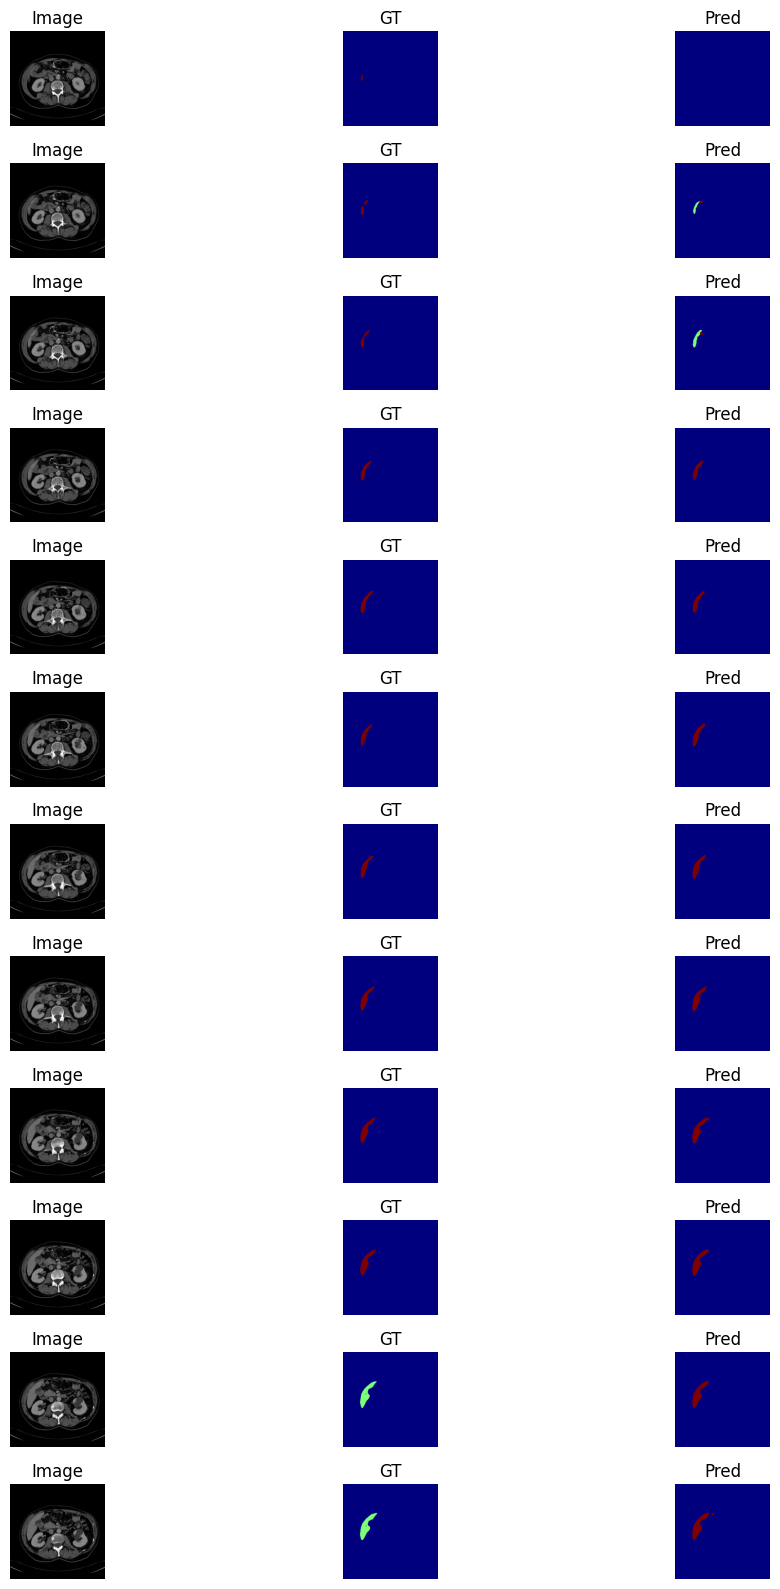

In [ ]:
best_model.eval()

max_images = 12  
shown = 0

plt.figure(figsize=(12, 4 * max_images // 3))

with torch.no_grad():
    for imgs_batch, masks_batch in test_loader:
        imgs_gpu = imgs_batch.to(device)

        if device == "cuda":
            with autocast():
                outputs = best_model(imgs_gpu)
        else:
            outputs = best_model(imgs_gpu)

        preds_batch = outputs.argmax(1).cpu().numpy()
        imgs_np  = imgs_batch.numpy()
        masks_np = masks_batch.numpy()

        for i in range(imgs_np.shape[0]):
            if shown >= max_images:
                break

            img = imgs_np[i, 0]

            plt.subplot(max_images, 3, shown*3 + 1)
            plt.imshow(img, cmap="gray")
            plt.title("Image")
            plt.axis("off")

            plt.subplot(max_images, 3, shown*3 + 2)
            plt.imshow(masks_np[i], cmap="jet")
            plt.title("GT")
            plt.axis("off")

            plt.subplot(max_images, 3, shown*3 + 3)
            plt.imshow(preds_batch[i], cmap="jet")
            plt.title("Pred")
            plt.axis("off")

            shown += 1

        if shown >= max_images:
            break

plt.tight_layout()
plt.show()


In [21]:
from skimage import measure
import trimesh
import plotly.graph_objects as go

target_pid = test_pids[0]
print("3D for patient:", target_pid)

patient_files = sorted([f for f in patient_map[target_pid]["files"]])

pred_slices = []

best_model.eval()
for fname in tqdm(patient_files, desc="3D Slices"):
    img = np.load(os.path.join(IMAGES_DIR, fname)).astype(np.float32)
    img = np.expand_dims(img, axis=-1)
    out = resize_only(image=img, mask=np.zeros_like(img[...,0]))
    img_resized = out["image"]
    img_t = torch.tensor(img_resized.transpose(2,0,1), dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        if device == "cuda":
            with autocast():
                logits = best_model(img_t)
        else:
            logits = best_model(img_t)
    pred = logits.argmax(1).cpu().numpy()[0]
    pred_slices.append(pred)

volume_pred = np.stack(pred_slices, axis=0)
print("Volume shape:", volume_pred.shape)

liver_vol = (volume_pred == 1).astype(np.uint8)
tumor_vol = (volume_pred == 2).astype(np.uint8)

print("Liver voxels:", liver_vol.sum())
print("Tumor voxels:", tumor_vol.sum())

verts_liver, faces_liver, _, _ = measure.marching_cubes(liver_vol, level=0.5)

verts_tumor, faces_tumor = None, None
if tumor_vol.sum() > 0:
    verts_tumor, faces_tumor, _, _ = measure.marching_cubes(tumor_vol, level=0.5)
else:
    print("No clear tumor mesh for this patient by model.")

fig = go.Figure()

fig.add_trace(go.Mesh3d(
    x=verts_liver[:, 0],
    y=verts_liver[:, 1],
    z=verts_liver[:, 2],
    i=faces_liver[:, 0],
    j=faces_liver[:, 1],
    k=faces_liver[:, 2],
    opacity=0.2,
    color='cyan',
    name='Liver'
))

if verts_tumor is not None:
    fig.add_trace(go.Mesh3d(
        x=verts_tumor[:, 0],
        y=verts_tumor[:, 1],
        z=verts_tumor[:, 2],
        i=faces_tumor[:, 0],
        j=faces_tumor[:, 1],
        k=faces_tumor[:, 2],
        opacity=1.0,
        color='red',
        name='Tumor'
    ))

fig.update_layout(
    title="3D Liver + Tumor",
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    width=800,
    height=700
)

fig.show()


3D for patient: 3Dircadb1.4


3D Slices: 100%|██████████| 67/67 [00:02<00:00, 29.09it/s]


Volume shape: (67, 256, 256)
Liver voxels: 291720
Tumor voxels: 1267
